# Exploratory Data Analysis

Compare post type, time, and engagement using the cleaned dataset.

**Student:** S. M. Monowar Kayser (253-25-019)  
**Course:** Data Visualization (CSE628), Summer 2026

All paths are project-relative and all reported values are calculated from the stored data or `outputs/analysis_summary.json`.

In [1]:
from pathlib import Path
import json
import sys
from IPython.display import Image, display
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
SUMMARY = json.loads((ROOT / 'outputs' / 'analysis_summary.json').read_text(encoding='utf-8'))
print('Project root resolved successfully.')
print('Canonical summary: outputs/analysis_summary.json')

Project root resolved successfully.
Canonical summary: outputs/analysis_summary.json


In [2]:
import pandas as pd
from src.config import PROCESSED_CSV
frame = pd.read_csv(PROCESSED_CSV, parse_dates=['status_published'])
by_type = frame.groupby('status_type')[['num_reactions','num_comments','num_shares','total_engagement']].agg(['count','mean','median']).round(2)
display(by_type)

num_reactions                num_comments                 \
                    count    mean median        count    mean median   
status_type                                                            
link                   63  370.14   50.0           63    5.70    1.0   
photo                4288  181.29   34.0         4288   15.99    2.0   
status                365  438.78  120.0          365   36.24   10.0   
video                2334  283.41  160.0         2334  642.48   39.0   

            num_shares                total_engagement                  
                 count    mean median            count     mean median  
status_type                                                             
link                63    4.40    0.0               63   380.24   53.0  
photo             4288    2.55    0.0             4288   199.84   40.0  
status             365    2.56    0.0              365   477.58  141.0  
video             2334  115.68   12.0             2334  1041.57  458.0

In [3]:
display(frame[['num_reactions','num_comments','num_shares','total_engagement']].corr(method='spearman').round(3))
display(frame.nlargest(10, 'total_engagement')[['status_id','status_type','status_published','total_engagement']])

,num_reactions,num_comments,num_shares,total_engagement
num_reactions,1.000,0.732,0.558,0.968
num_comments,0.732,1.000,0.624,0.827
num_shares,0.558,0.624,1.000,0.662
total_engagement,0.968,0.827,0.662,1.000


,status_id,status_type,status_published,total_engagement
2178,499,video,2016-11-30 08:46:00,21708
2197,481,video,2016-12-09 21:48:00,19626
3086,6758,video,2017-09-25 10:35:00,19025
4573,3247,video,2018-01-08 01:10:00,13483
3061,6763,video,2017-09-21 08:01:00,12377
6165,3893,video,2018-05-09 08:17:00,11909
2983,6800,video,2017-09-09 10:05:00,11908
5173,6449,video,2018-02-27 10:29:00,11555
3030,6776,video,2017-09-16 10:00:00,10845
3682,6660,photo,2017-11-24 02:23:00,10491


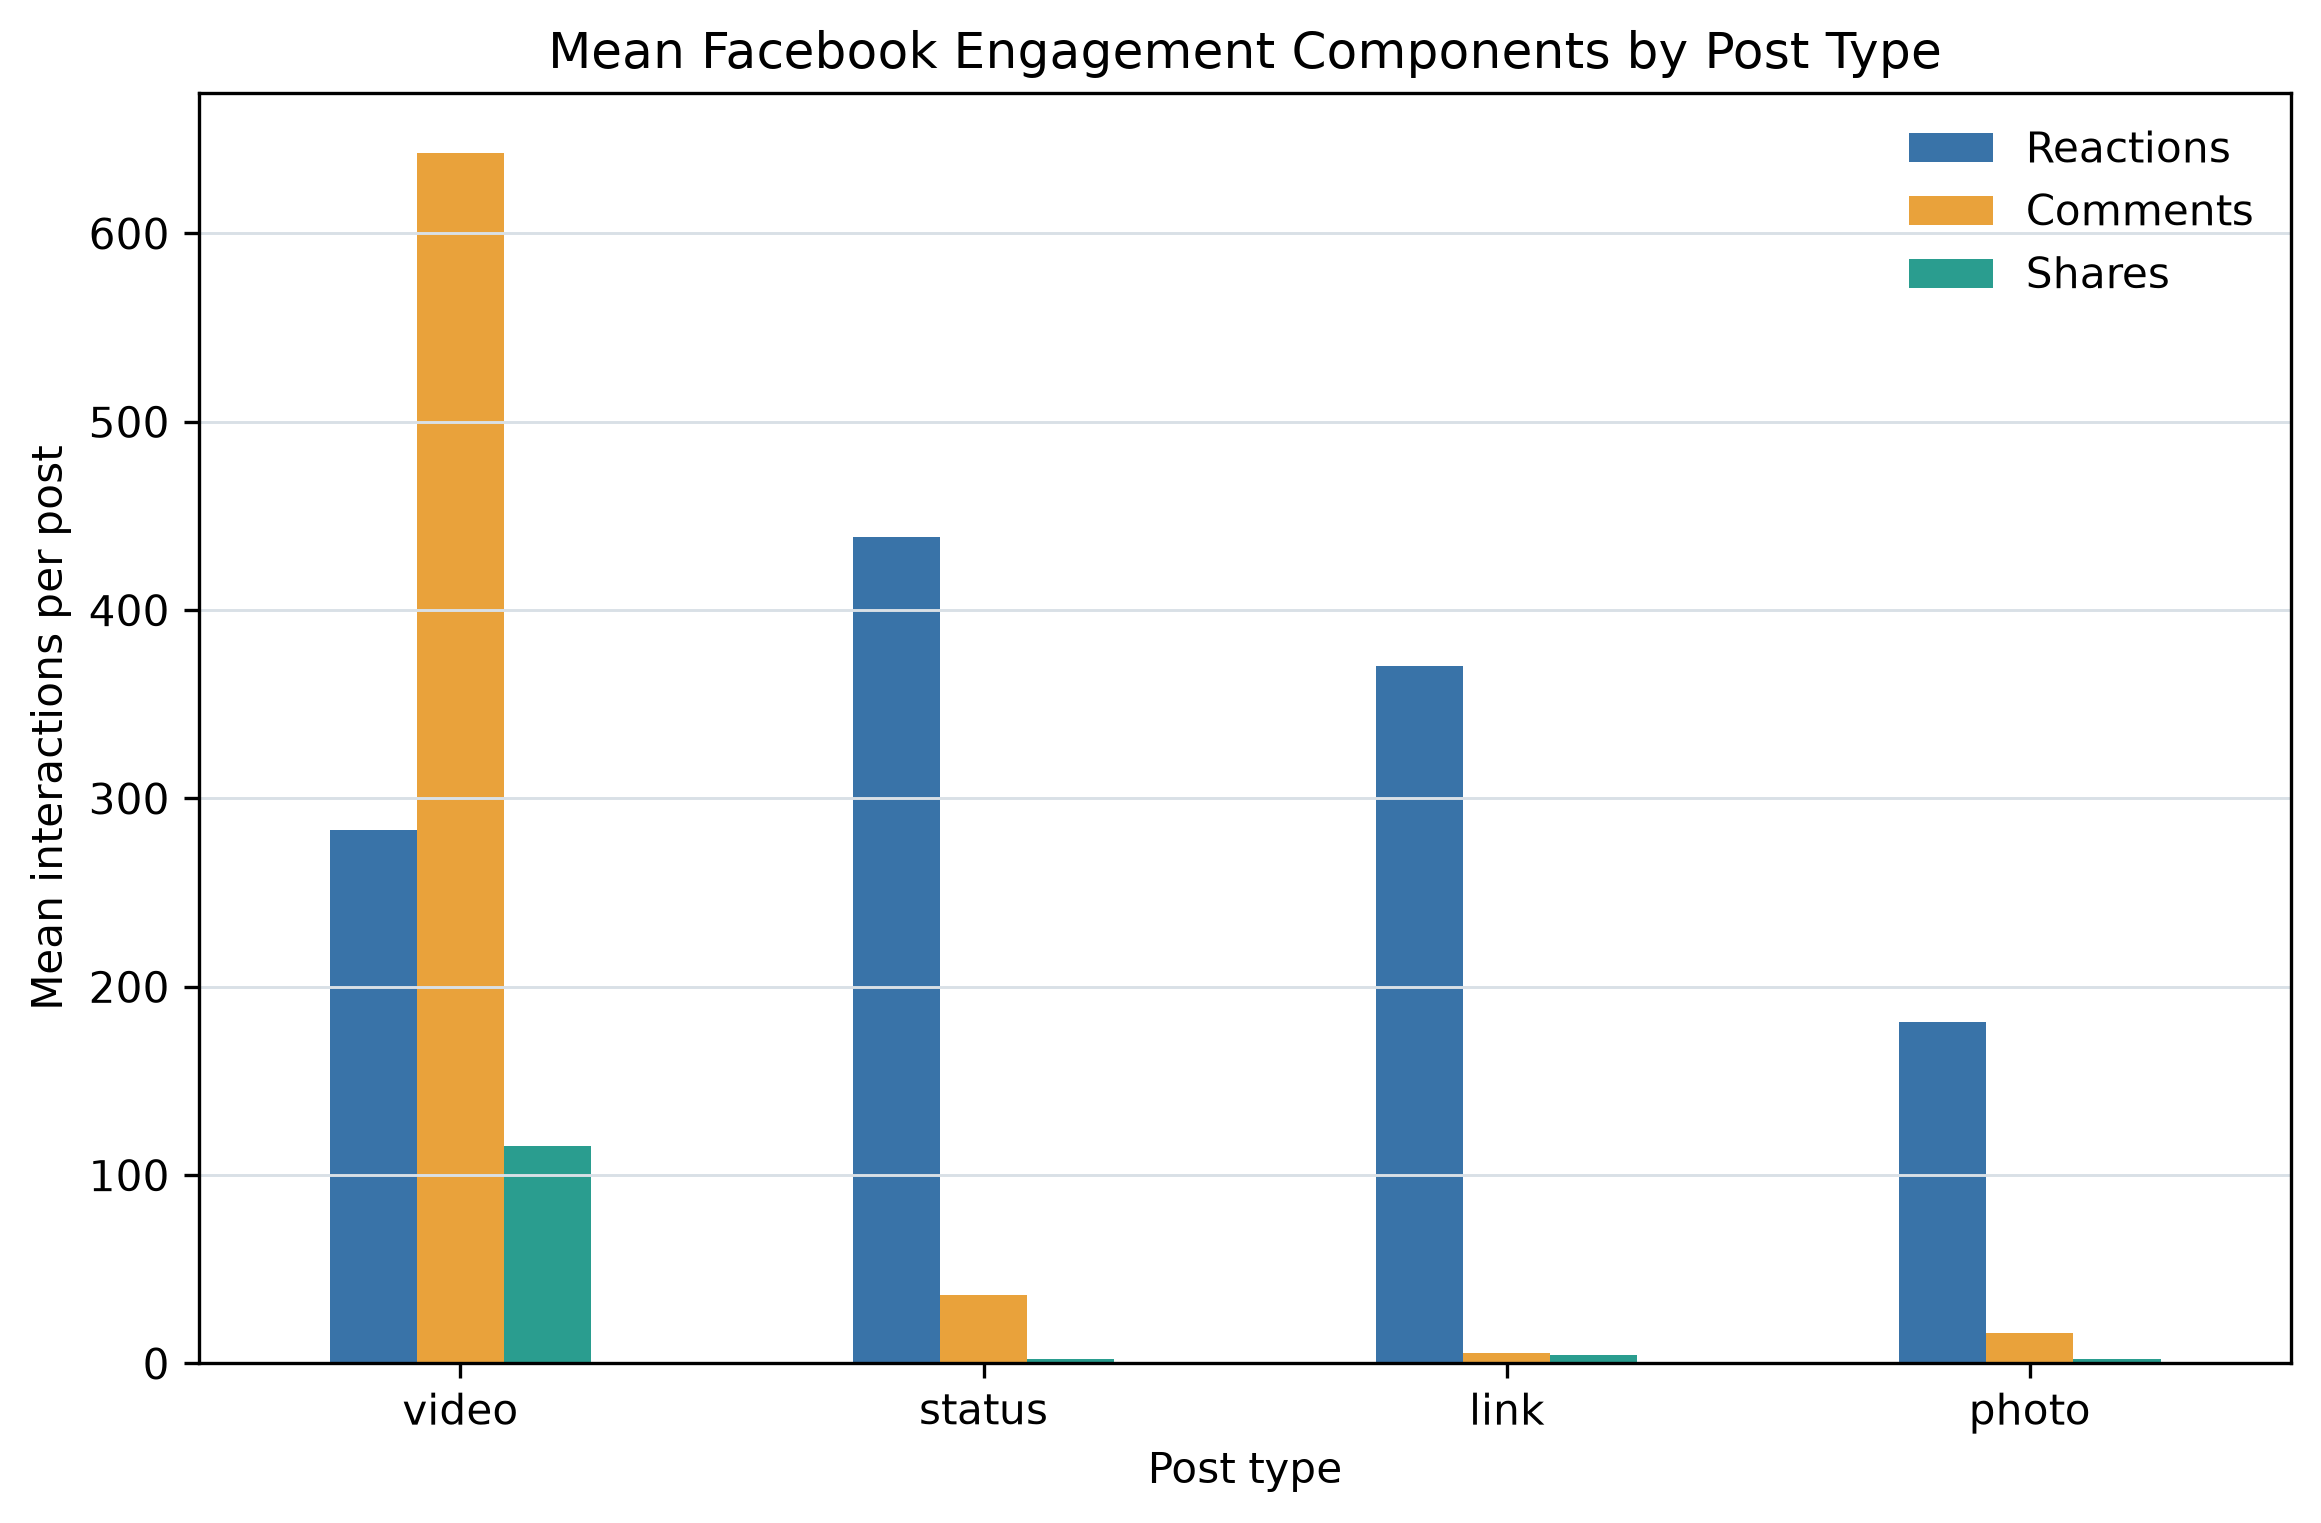

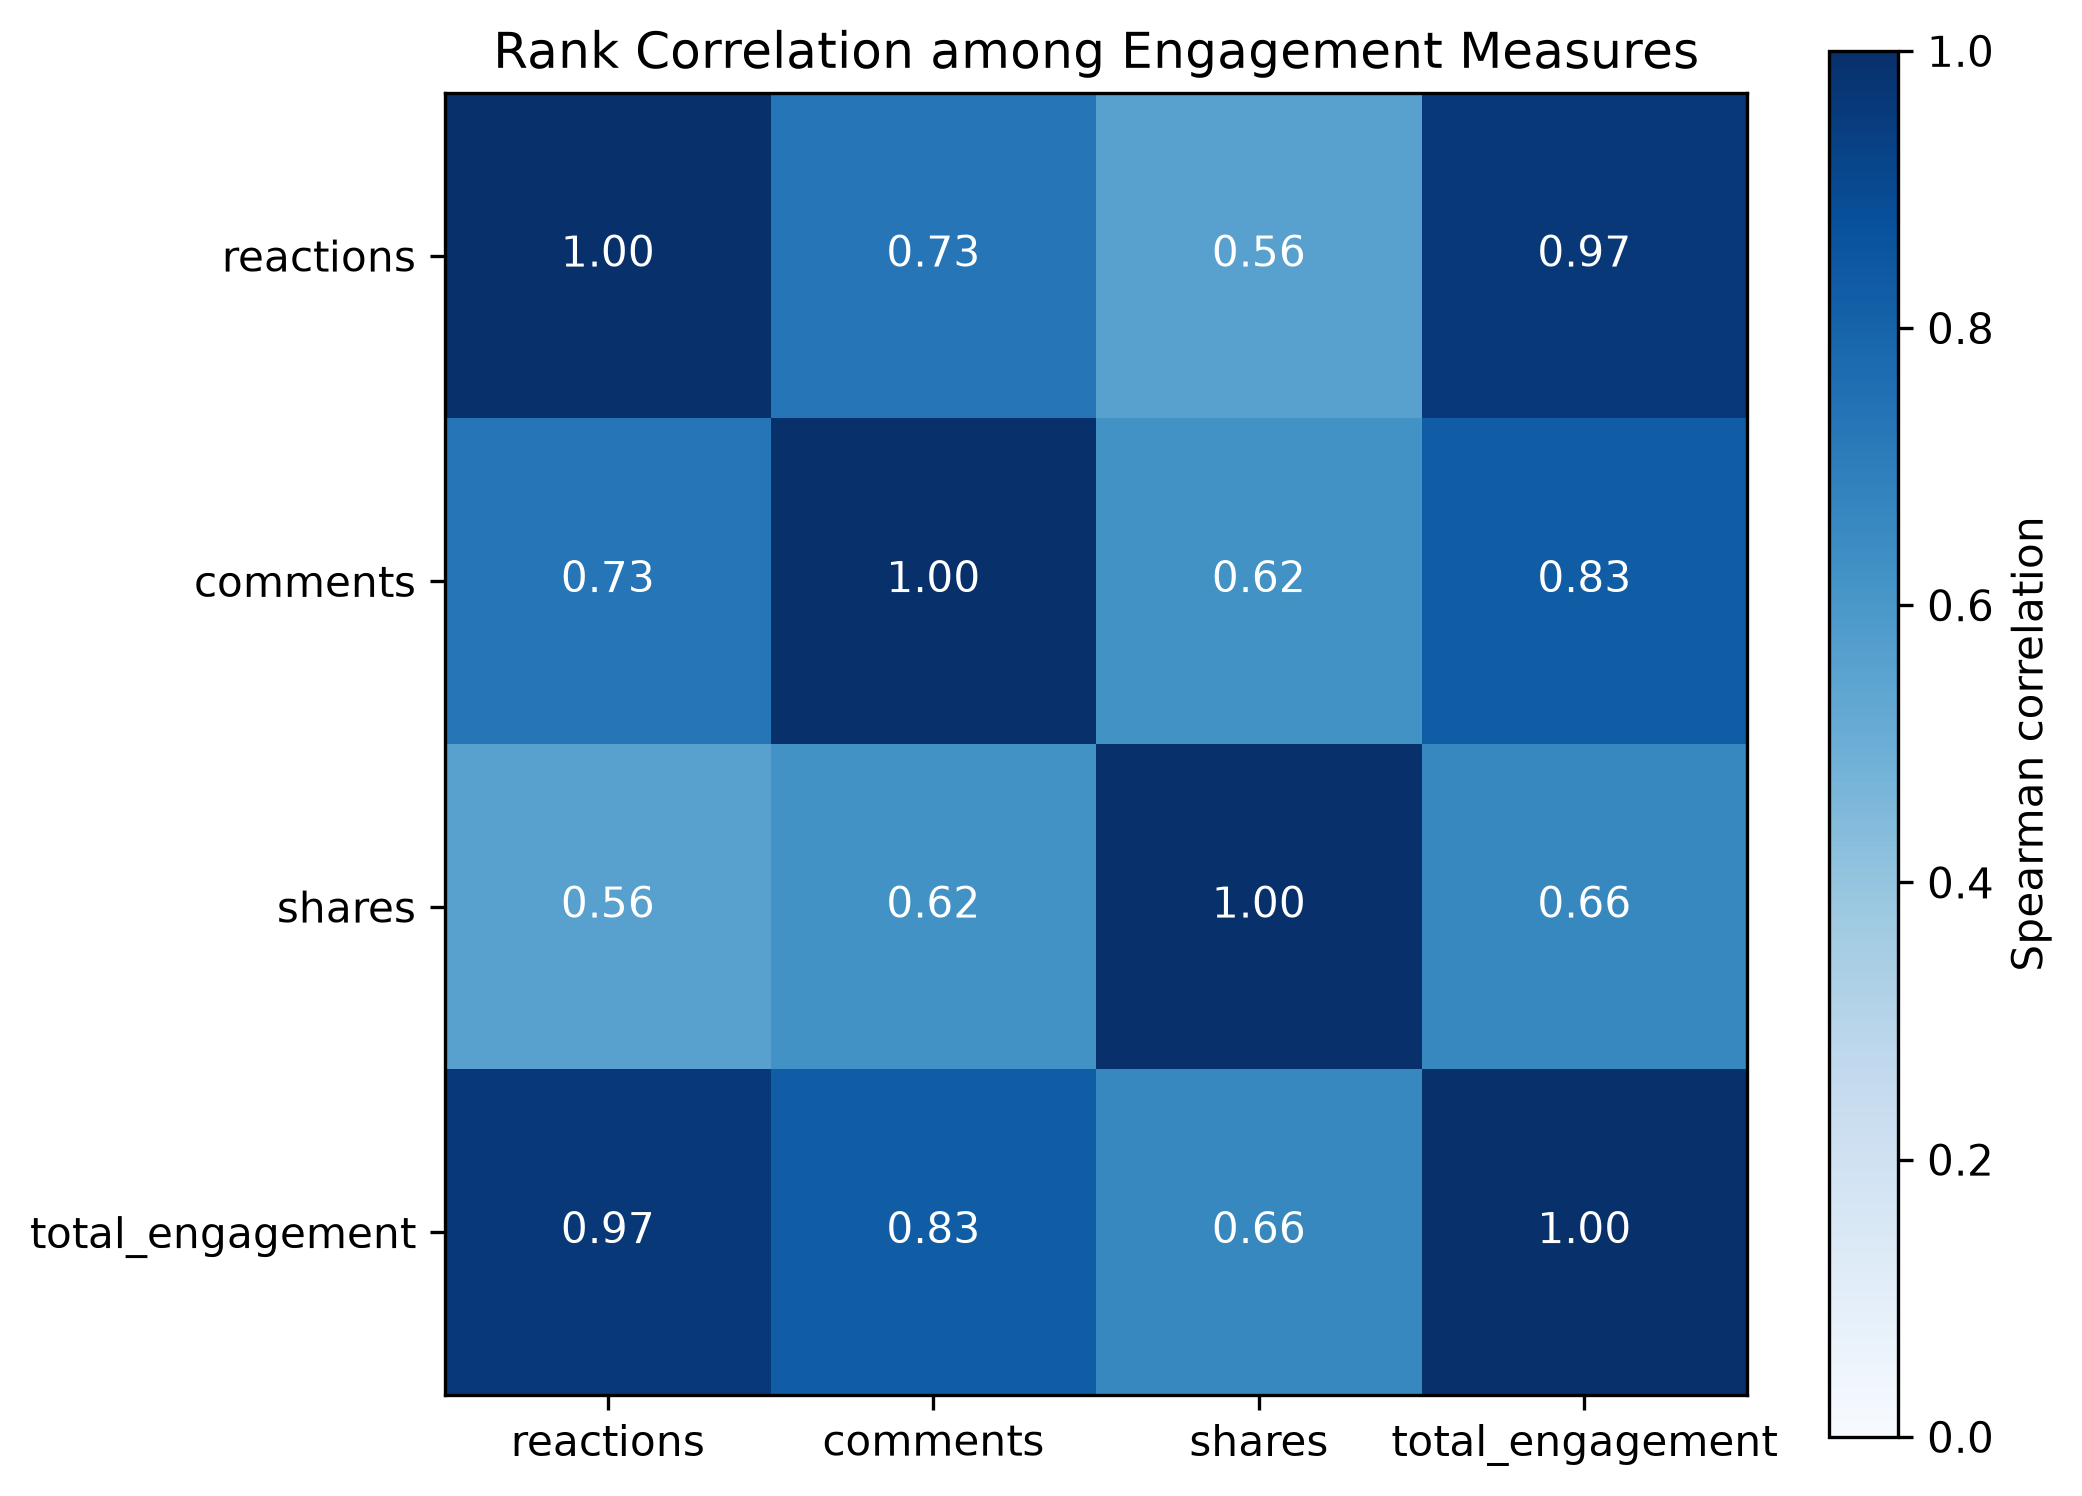

In [4]:
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'engagement_by_post_type.png')))
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'engagement_correlation.png')))

Means and medians are reported together because engagement is strongly right-skewed. Correlations describe monotonic association and are not interpreted as causal effects.